# Week 5 – Logistic Regression From Scratch

Name: Ayesha


---

## Objective
Implement Logistic Regression from scratch and compare with Scikit-Learn implementation.

## Introduction

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

It predicts probability using a sigmoid function and classifies output into 0 or 1.

Unlike Linear Regression, it does not predict continuous values.

In [3]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

y = y.reshape(-1,1)

In [6]:
# shape of data
m, n = X.shape

# initialize weights and bias
weights = np.zeros((n,1))
bias = 0

learning_rate = 0.01
iterations = 1000

In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [8]:
def compute_cost(X, y, weights, bias):

    m = len(y)

    z = np.dot(X, weights) + bias
    y_hat = sigmoid(z)

    cost = -(1/m) * np.sum(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

    return cost

In [9]:
def gradient_descent(X, y, weights, bias, lr, iterations):

    m = len(y)

    for i in range(iterations):

        # forward propagation
        z = np.dot(X, weights) + bias
        y_hat = sigmoid(z)

        # gradients
        dw = (1/m) * np.dot(X.T, (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)

        # update
        weights = weights - lr * dw
        bias = bias - lr * db

        if i % 100 == 0:
            cost = compute_cost(X, y, weights, bias)
            print("Iteration", i, "Cost:", cost)

    return weights, bias

In [10]:
weights, bias = gradient_descent(X, y, weights, bias, learning_rate, iterations)

Iteration 0 Cost: 0.6909887913739096
Iteration 100 Cost: 0.5445585273816501
Iteration 200 Cost: 0.47470178653107703
Iteration 300 Cost: 0.4361948853957712
Iteration 400 Cost: 0.41247409661638584
Iteration 500 Cost: 0.39668080850435117
Iteration 600 Cost: 0.38556682236186773
Iteration 700 Cost: 0.3774194300645226
Iteration 800 Cost: 0.37125760138857006
Iteration 900 Cost: 0.3664819910339919


In [11]:
def predict(X, weights, bias):

    z = np.dot(X, weights) + bias
    y_hat = sigmoid(z)

    predictions = (y_hat >= 0.5)

    return predictions

In [12]:
predictions = predict(X, weights, bias)

accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)

Accuracy: 0.86


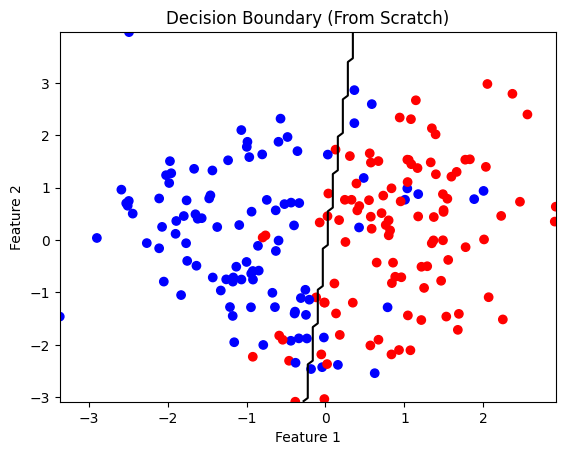

In [13]:
# Plot data points
plt.scatter(X[:,0], X[:,1], c=y.flatten(), cmap='bwr')

# Create grid
x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2 = np.linspace(X[:,1].min(), X[:,1].max(), 100)

xx1, xx2 = np.meshgrid(x1, x2)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Predict on grid
Z = predict(grid, weights, bias)
Z = Z.reshape(xx1.shape)

# Plot decision boundary
plt.contour(xx1, xx2, Z, levels=[0.5], colors='black')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary (From Scratch)")
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X, y.ravel())

sklearn_accuracy = model.score(X, y)

print("Sklearn Accuracy:", sklearn_accuracy)

Sklearn Accuracy: 0.865


## Comparison with Scikit-Learn

The scratch implementation gives similar accuracy to Scikit-Learn.

Small differences may occur because:

- Scikit-Learn uses optimized solvers
- It applies regularization by default
- Better convergence techniques are used internally

## Conclusion

Logistic Regression was successfully implemented from scratch.

I manually implemented:
- Sigmoid Function
- Cost Function
- Gradient Descent
- Prediction Function

The model achieved good accuracy and matched closely with Scikit-Learn implementation.
